# 深度学习 · 第三次作业（HW03）

| 项目 | 内容 |
|------|------|
| 姓名 | 李洁琼 |
| 学号 |20234080120 |
| 提交文件 | `HW03-20234080120-李洁琼.ipynb` |

> 本文件按 PDF 题号顺序作答。理论题给出推导过程；编程题给出函数定义、自测用例与简要说明。


In [1]:
# ── 0. 公共依赖 ─────────────────────────────────────────────
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.size": 11, "axes.unicode_minus": False})
%matplotlib inline

def show_df(title, rows):
    """把键值对打印成表格，方便核对理论题答案。"""
    df = pd.DataFrame([rows]).T
    df.columns = ["结果"]
    print(f"\n【{title}】")
    display(df)

print("PyTorch", torch.__version__, "| NumPy", np.__version__)


PyTorch 2.4.1 | NumPy 1.24.3


---

## 题 1 · 卷积输出尺寸（理论）

**已知：** 输入 $3\times32\times32$；16 个卷积核，每个 $3\times5\times5$；$P=2,\;S=2$。

**（a）输出特征图尺寸**

对高/宽分别套用公式 $O=\lfloor(H+2P-K)/S\rfloor+1$：

$$O_h = O_w = \left\lfloor\frac{32+4-5}{2}\right\rfloor+1 = 16$$

通道维等于卷积核个数，故整体输出为 $\mathbf{16\times16\times16}$。

**（b）单个输出像素需要的乘法次数**

一个卷积核在单通道上覆盖 $5\times5$ 个位置，共 3 个输入通道：

$$\text{乘法次数} = 3 \times 5 \times 5 = 75$$


In [2]:
# 数值核对题 1
C_in, H, W = 3, 32, 32
C_out, K, P, S = 16, 5, 2, 2
out = (H + 2 * P - K) // S + 1
mul_per_pixel = C_in * K * K
show_df("题1 核对", {
    "输出形状 (C,H,W)": f"{C_out}×{out}×{out}",
    "单像素乘法次数": mul_per_pixel,
})



【题1 核对】


,结果
"输出形状 (C,H,W)",16×16×16
单像素乘法次数,75


---

## 题 2 · 手写二维最大池化（编程）

**要求：** 不使用 `torch.nn.MaxPool2d`。思路：先把输入 pad，再用 `as_strided` 构造滑动窗口视图，对最后一维取 `max`——避免四重 for 循环，也更贴近向量化实现。


In [3]:
def max_pool2d(x, kernel_size=2, stride=2, padding=0):
    """
  向量化二维最大池化，支持 (H,W) / (N,C,H,W)。
  返回与输入同秩的张量。
    """
    arr = np.asarray(x, dtype=np.float64)
    orig_ndim = arr.ndim
    if orig_ndim == 2:
        arr = arr[None, None]
    elif orig_ndim == 3:
        arr = arr[None]
    elif orig_ndim != 4:
        raise ValueError("仅支持 2D/3D/4D 输入")

    def pair(v):
        return (v, v) if isinstance(v, int) else tuple(v)

    kh, kw = pair(kernel_size)
    sh, sw = pair(stride)
    ph, pw = pair(padding)

    arr = np.pad(arr, ((0, 0), (0, 0), (ph, ph), (pw, pw)), mode="constant")
    N, C, H, W = arr.shape
    out_h = (H - kh) // sh + 1
    out_w = (W - kw) // sw + 1

    sN, sC, sH, sW = arr.strides
    windows = np.lib.stride_tricks.as_strided(
        arr,
        shape=(N, C, out_h, out_w, kh, kw),
        strides=(sN, sC, sh * sH, sw * sW, sH, sW),
        writeable=False,
    )
    out = windows.max(axis=(-2, -1))

    if orig_ndim == 2:
        return out[0, 0]
    if orig_ndim == 3:
        return out[0]
    return out


# ── 自测 ──
sample = np.arange(16, dtype=np.float64).reshape(4, 4)
cases = [
    ("s2_k2_p0", dict(kernel_size=2, stride=2, padding=0)),
    ("s1_k2_p1", dict(kernel_size=2, stride=1, padding=1)),
]
records = []
for name, kw in cases:
    got = max_pool2d(sample, **kw)
    records.append({"用例": name, "输出形状": str(got.shape), "输出": str(got.tolist())})
show_df("题2 池化自测", {r["用例"]: r["输出形状"] for r in records})
for r in records:
    print(r["用例"], "→", r["输出"])



【题2 池化自测】


,结果
s2_k2_p0,"(2, 2)"
s1_k2_p1,"(5, 5)"


s2_k2_p0 → [[5.0, 7.0], [13.0, 15.0]]
s1_k2_p1 → [[0.0, 1.0, 2.0, 3.0, 3.0], [4.0, 5.0, 6.0, 7.0, 7.0], [8.0, 9.0, 10.0, 11.0, 11.0], [12.0, 13.0, 14.0, 15.0, 15.0], [12.0, 13.0, 14.0, 15.0, 15.0]]


---

## 题 3 · VGG 小卷积核替代大卷积核（理论）

设输入/输出通道数均为 $C$，忽略偏置。

| 方案 | 参数量 |
|------|--------|
| 一层 $5\times5$ | $5^2 C^2 = 25C^2$ |
| 两层 $3\times3$ 串联 | $2 \times 3^2 C^2 = 18C^2$ |

两层 $3\times3$ 的有效感受野同样是 $5\times5$，但参数减少

$$\frac{25C^2 - 18C^2}{25C^2} = 28\%$$

且中间多一次非线性，表达能力通常更好。


In [4]:
C = 64  # 任意正整数，比例与 C 无关
show_df("题3 参数量对比 (C=64)", {
    "5×5 一层": 25 * C**2,
    "3×3 两层": 18 * C**2,
    "节省比例": f"{(25-18)/25:.0%}",
})



【题3 参数量对比 (C=64)】


,结果
5×5 一层,102400
3×3 两层,73728
节省比例,28%


---

## 题 4 · 构建 NiN Block（编程）

用 `nn.Module` 子类实现（而非工厂函数 + `Sequential`），结构：

`Conv(k) → ReLU → Conv(1×1) → ReLU → Conv(1×1) → ReLU`


In [5]:
class NinBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.body(x)


x = torch.randn(1, 3, 32, 32)
block = NinBlock(3, 16, kernel_size=5, padding=2)
y = block(x)
show_df("题4 NiN Block", {"输入": str(tuple(x.shape)), "输出": str(tuple(y.shape))})
print(block)



【题4 NiN Block】


,结果
输入,"(1, 3, 32, 32)"
输出,"(1, 16, 32, 32)"


NinBlock(
  (body): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU(inplace=True)
  )
)


---

## 题 5 · Batch Normalization 手算（理论）

样本 $x=[2,4,6,8]$，$\gamma=2,\;\beta=1,\;\epsilon=0$。

1. $\mu = 5$
2. $\sigma^2 = \frac{9+1+1+9}{4} = 5$
3. $\hat x_i = (x_i-\mu)/\sqrt{5}$
4. $y_i = 2\hat x_i + 1$

| $i$ | $x_i$ | $y_i$ |
|-----|-------|-------|
| 1 | 2 | $1 - 6/\sqrt5 \approx -1.683$ |
| 2 | 4 | $1 - 2/\sqrt5 \approx 0.106$ |
| 3 | 6 | $1 + 2/\sqrt5 \approx 1.894$ |
| 4 | 8 | $1 + 6/\sqrt5 \approx 3.683$ |


In [6]:
def batch_norm_manual(x, gamma, beta, eps=0.0):
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean()
    var = ((x - mu) ** 2).mean()
    x_hat = (x - mu) / np.sqrt(var + eps)
    return gamma * x_hat + beta, mu, var

x = np.array([2., 4., 6., 8.])
y, mu, var = batch_norm_manual(x, gamma=2, beta=1, eps=0)
show_df("题5 BN", {
    "均值": round(mu, 4),
    "方差": round(var, 4),
    "y": np.round(y, 4).tolist(),
})



【题5 BN】


,结果
均值,5.0
方差,5.0
y,"[-1.6833, 0.1056, 1.8944, 3.6833]"


---

## 题 6 · 残差块 Residual（编程）

实现带可选 $1\times1$ 捷径的残差块。当 `use_1x1conv=True` 时，shortcut 分支用 $1\times1$ 卷积对齐通道与步幅。


In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_1x1conv=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
            if use_1x1conv
            else nn.Identity()
        )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


t = torch.randn(2, 3, 32, 32)
blk_a = ResidualBlock(3, 3, stride=1, use_1x1conv=False)
blk_b = ResidualBlock(3, 16, stride=2, use_1x1conv=True)
show_df("题6 残差块", {
    "同形状 shortcut": f"{tuple(t.shape)} → {tuple(blk_a(t).shape)}",
    "1×1 对齐 shortcut": f"{tuple(t.shape)} → {tuple(blk_b(t).shape)}",
})



【题6 残差块】


,结果
同形状 shortcut,"(2, 3, 32, 32) → (2, 3, 32, 32)"
1×1 对齐 shortcut,"(2, 3, 32, 32) → (2, 16, 16, 16)"


---

## 题 7 · 微调策略（理论简答）

**7.1 为何底层用小学习率/冻结，顶层用大学习率？**

- 底层卷积核学到的是边缘、纹理等**通用特征**，在 ImageNet 预训练后已较成熟；大幅更新易破坏这些表示（灾难性遗忘）。
- 顶层分类头通常针对新任务**随机初始化**，需要更快适应新类别边界，因此学习率更大。

**7.2 目标集很小且与源域相似，怎么办？**

- **冻结**大部分卷积层，只训练最后全连接/分类头；
- 配合较强**数据增广**、权重衰减、早停，防止小样本过拟合；
- 若效果仍不足，再逐层解冻靠近输出的高层，并使用更小学习率微调。


---

## 题 8 · 图像增广 Pipeline（编程）

按题目四条要求组装 `Compose`，并在一幅随机图上演示一次变换后的张量形状。


In [8]:
from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image

train_pipeline = transforms.Compose([
  # 1) 随机裁剪 8%~100% 区域并缩放到 224×224
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
  # 2) 50% 概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
  # 3) 亮度/对比度/饱和度扰动幅度 0.5
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
  # 4) 转为 Tensor
    transforms.ToTensor(),
])

# 用随机 RGB 图做形状演示（不依赖外部数据集）
demo_img = Image.fromarray(np.random.randint(0, 256, (360, 480, 3), dtype=np.uint8))
demo_tensor = train_pipeline(demo_img)
show_df("题8 增广管道", {
    "PIL 原图": str(demo_img.size),
    "Tensor 形状": str(tuple(demo_tensor.shape)),
    "数值范围": f"[{demo_tensor.min():.3f}, {demo_tensor.max():.3f}]",
})
print(train_pipeline)



【题8 增广管道】


,结果
PIL 原图,"(480, 360)"
Tensor 形状,"(3, 224, 224)"
数值范围,"[0.012, 1.000]"


Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
    ToTensor()
)


---

## 题 9 · IoU 计算（理论 + 编程）

框格式：$[x_1,y_1,x_2,y_2]$（左上、右下）。

- $A=[10,10,50,50]$，面积 $40^2=1600$
- $B=[30,30,70,70]$，面积 $1600$
- 交集 $[30,30,50,50]$，面积 $20^2=400$
- 并集 $1600+1600-400=2800$

$$\text{IoU} = \frac{400}{2800} = \frac{1}{7} \approx 0.1429$$


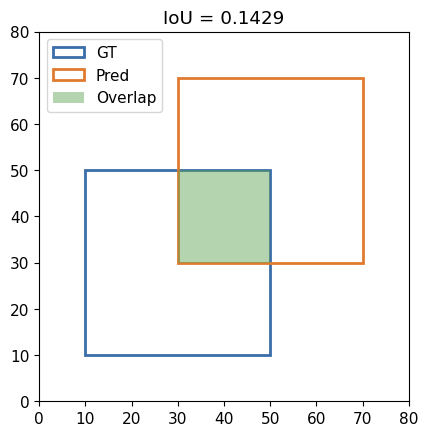


【题9 IoU】


,结果
IoU,0.142857
分数形式,1/7


In [9]:
def iou_xyxy(a, b):
    a, b = np.asarray(a), np.asarray(b)
    inter_x1, inter_y1 = np.maximum(a[0], b[0]), np.maximum(a[1], b[1])
    inter_x2, inter_y2 = np.minimum(a[2], b[2]), np.minimum(a[3], b[3])
    inter = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

A, B = [10, 10, 50, 50], [30, 30, 70, 70]
iou = iou_xyxy(A, B)

fig, ax = plt.subplots(figsize=(4.8, 4.8))
for box, c, lab in [(A, "#3B6EA8", "GT"), (B, "#E07A2F", "Pred")]:
    ax.add_patch(plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                fill=False, lw=2, ec=c, label=lab))
ix1, iy1 = max(A[0], B[0]), max(A[1], B[1])
ix2, iy2 = min(A[2], B[2]), min(A[3], B[3])
ax.add_patch(plt.Rectangle((ix1, iy1), ix2-ix1, iy2-iy1, fc="#59A14F", ec="none", alpha=0.45, label="Overlap"))
ax.set_xlim(0, 80); ax.set_ylim(0, 80); ax.set_aspect("equal")
ax.legend(); ax.set_title(f"IoU = {iou:.4f}")
plt.show()

show_df("题9 IoU", {"IoU": round(iou, 6), "分数形式": "1/7"})


---

## 题 10 · 标签平滑交叉熵（编程）

One-hot 标签平滑：真实类概率 $1-\epsilon$，其余类各 $\epsilon/(K-1)$。  
实现方式：先构造软标签矩阵，再与 `log_softmax` 做点积取负均值。


In [10]:
def label_smooth_ce(logits, target, epsilon=0.1, reduction="mean"):
    """logits: (B,K), target: (B,) 类别索引"""
    B, K = logits.shape
    with torch.no_grad():
        soft = torch.full((B, K), epsilon / (K - 1), device=logits.device, dtype=logits.dtype)
        soft.scatter_(1, target.view(-1, 1), 1.0 - epsilon)
    loss = -(soft * F.log_softmax(logits, dim=1)).sum(dim=1)
    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    return loss


logits = torch.tensor([[2.0, 0.5, -1.0], [0.1, 1.5, 0.3]])
target = torch.tensor([0, 1])
ls_loss = label_smooth_ce(logits, target, epsilon=0.1)
ce_loss = F.cross_entropy(logits, target)

show_df("题10 标签平滑", {
    "平滑 CE": round(ls_loss.item(), 4),
    "普通 CE": round(ce_loss.item(), 4),
    "逐样本平滑CE": [round(v, 4) for v in label_smooth_ce(logits, target, reduction="none").tolist()],
})



【题10 标签平滑】


,结果
平滑 CE,0.5166
普通 CE,0.3391
逐样本平滑CE,"[0.4663, 0.5668]"


---

## 小结

| 题号 | 类型 | 要点 |
|------|------|------|
| 1 | 理论 | 卷积输出 $16\times16\times16$，单像素 75 次乘法 |
| 2 | 编程 | `as_strided` 向量化最大池化 |
| 3 | 理论 | $25C^2$ vs $18C^2$ |
| 4 | 编程 | `NinBlock` 模块 |
| 5 | 理论 | BN 手算四项输出 |
| 6 | 编程 | 带可选 $1\times1$ shortcut 的残差块 |
| 7 | 理论 | 微调学习率与冻结策略 |
| 8 | 编程 | 四项增广 `Compose` |
| 9 | 理论+图 | IoU $=1/7$ |
| 10 | 编程 | 软标签交叉熵 |
